In [31]:
import pandas as pd
import numpy as np
import re
from typing import Tuple, List, Optional, Dict
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings("ignore")

In [32]:
from data.MarmosetData import MarmosetData

m = MarmosetData("data/marm_data_wide_clustered_classif.csv")
print(m.treatments)


{'MOX', 'DEL', 'DEL+QBS', 'EMB+MOX+PZA+RIF', 'BDQ+DEL', 'PZA+RIF', 'BDQ+DEL+QBS', 'PZA', 'MOX+RIF', 'LIN+PRE', 'BDQ+QBS', 'BDQ+PRE', 'BDQ', 'INH', 'LIN', 'RIF', 'QBS', 'INH+PZA', 'BDQ+LIN', 'EMB+INH+PZA+RIF', 'PRE', 'BDQ+LIN+PRE'}


In [33]:
def load_and_process_data(in_vitro: str = "data/in_vitro_modeling.csv", marmoset: str = "data/marm_data_wide_clustered_classif.csv") -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load and process data for in vitro and marmoset datasets."""
    try: 
        in_vitro = pd.read_csv(in_vitro)
        
        in_vitro = in_vitro[in_vitro["Drug"].str.contains("\+", na=False)]
        
        
        marmoset = pd.read_csv(marmoset)
        
        print(f"In vitro data shape: {in_vitro.shape}")
        print(f"Marmoset data shape: {marmoset.shape}")
        
        return in_vitro, marmoset

    except Exception as e:
        print(f"Error loading data: {e}")
        return None, None

In [34]:
def identify_pathology_features(marmoset_df: pd.DataFrame) -> Tuple[List[str], List[str], List[str]]:
    """
    Identify pathology features in marmoset dataset.
    Returns a list of:
    - All common features between TP2 and TP6
    - TP2 feature columns
    - TP6 feature columns
    """
    
    all_cols = marmoset_df.columns.tolist()
    
    # feature selection
    tp2_cols = [c for c in all_cols if c.startswith('TP2_') and not any(x in c for x in ['LesionType', 'FinalLesionType', 'Consolidate', 'Contour'])]
    tp6_cols = [c for c in all_cols if c.startswith('TP6_') and not any(x in c for x in ['LesionType', 'FinalLesionType', 'Consolidate', 'Contour'])]

    # base feature names
    tp2_base = [c.replace('TP2_', '') for c in tp2_cols]
    tp6_base = [c.replace('TP6_', '') for c in tp6_cols]

    # common features
    common_features = list(set(tp2_base) & set(tp6_base))
    
    print(f"Found {len(common_features)} common features between TP2 and TP6.")
    
    return common_features, tp2_cols, tp6_cols

In [35]:
def calculate_deltas(marmoset_df: pd.DataFrame, common_features: List[str]) -> pd.DataFrame:
    """
    Calculate deltas (TP6-TP2) for pathology features.
    Deltas are calculated in such a way that negative values indicate improvement.
    """
    
    delta_df = marmoset_df.copy()
    
    for feature in common_features:
        tp6_col = f'TP6_{feature}'
        tp2_col = f'TP2_{feature}'
        delta_col = f'delta_{feature}'
        
        if tp6_col in marmoset_df.columns and tp2_col in marmoset_df.columns:
            delta_df[delta_col] = marmoset_df[tp6_col] - marmoset_df[tp2_col]
    
    return delta_df

In [36]:
def get_correlation_features(in_vitro_df: pd.DataFrame, marmoset_df: pd.DataFrame, common_features: List[str]) -> Tuple[List[str], List[str]]:
    """Get lists of features for correlation analysis."""
    
    # in vitro features
    in_vitro_features = [col for col in in_vitro_df.columns if col != 'Drug']
    
    # TP6 features
    tp6_features = [f'TP6_{feature}' for feature in common_features]
    
    # TP2 features
    tp2_features = [f'TP2_{feature}' for feature in common_features]
    
    # delta features
    delta_features = [f'delta_{feature}' for feature in common_features]
    
    # all pathology features
    all_pathology_features = tp6_features + delta_features # TP2 is start of treatment so meaningless for correlations
    
    print(f"In vitro features: {len(in_vitro_features)}")
    print(f"TP6 features: {len(tp6_features)}")
    print(f"Delta features: {len(delta_features)}")
    
    return in_vitro_features, all_pathology_features

In [37]:
def filter_in_vitro_features(features: List[str],
                            exclude_prefixes: List[str] = None,
                            exclude_substrings: List[str] = None) -> List[str]:
    exclude_prefixes = exclude_prefixes or []
    exclude_substrings = exclude_substrings or []
    out = []
    
    for f in features:
        if any(f.startswith(p) for p in exclude_prefixes):
            continue
        if any (s in f for s in exclude_substrings):
            continue
        out.append(f)
    
    return out

In [38]:
def calculate_correlations_by_severity_aggregated(
    in_vitro_df: pd.DataFrame,
    delta_df: pd.DataFrame,
    in_vitro_features: List[str],
    pathology_features: List[str],
    severity: str,
    agg: str = 'mean',
    n_boot: int = 500,
    ci: float = 0.95,
    random_state: Optional[int] = 42
) -> Dict[str, np.ndarray]:
    """
    Aggregate lesion-level pathology features to the compound level (mean/median)
    and compute Spearman correlations across compounds. Optionally perform
    block bootstrap over compounds to obtain percentile CIs and empirical p-values.

    Returns a dict of matrices keyed by: 'rho', 'p', 'n', 'ci_low', 'ci_high', 'boot_p'.
    """
    if agg not in {'mean', 'median'}:
        raise ValueError("agg must be 'mean' or 'median'")

    # filter by severity
    severity_data = delta_df[delta_df['classif'] == severity].copy()
    if len(severity_data) == 0:
        raise ValueError(f"No data found for severity: {severity}. Options are: {delta_df['classif'].unique()}.")

    # uppercase for joins
    in_vitro_df = in_vitro_df.copy()
    in_vitro_df['COMP_UP'] = in_vitro_df['Drug'].str.upper()
    severity_data = severity_data.copy()
    severity_data['COMP_UP'] = severity_data['Compound'].str.upper()

    # common compounds
    common_compounds = sorted(set(in_vitro_df['COMP_UP']) & set(severity_data['COMP_UP']))
    print("!!!! COMMON COMPOUNDS !!!!")
    print(common_compounds)
    if len(common_compounds) < 3:
        print(f"[WARNING]: Only {len(common_compounds)} common compounds found for {severity} severity.")
        return {k: None for k in ['rho','p','n','ci_low','ci_high','boot_p']}

    print(f"Aggregated correlation for {severity} lesions across {len(common_compounds)} compounds using {agg}.")

    # aggregate pathology per compound for all requested features
    grouped = severity_data[severity_data['COMP_UP'].isin(common_compounds)].groupby('COMP_UP')[pathology_features]
    if agg == 'mean':
        path_agg = grouped.mean()
    else:
        path_agg = grouped.median()

    # prepare result matrices
    m = len(in_vitro_features)
    n = len(pathology_features)
    rho_matrix = np.full((m, n), np.nan)
    p_matrix = np.full((m, n), np.nan)
    n_matrix = np.zeros((m, n), dtype=int)
    ci_low_matrix = np.full((m, n), np.nan)
    ci_high_matrix = np.full((m, n), np.nan)
    boot_p_matrix = np.full((m, n), np.nan)

    rng = np.random.default_rng(random_state) if n_boot and n_boot > 0 else None
    alpha = 1 - ci

    # build in vitro feature frame keyed by compound
    iv_all = in_vitro_df.set_index('COMP_UP')

    for i, iv_feature in enumerate(in_vitro_features):
        iv_series_full = iv_all[iv_feature] if iv_feature in iv_all.columns else None
        if iv_series_full is None:
            continue
        for j, path_feature in enumerate(pathology_features):
            # intersect compounds with non-missing data for this pair
            path_col = path_agg[path_feature]
            both = pd.concat([iv_series_full, path_col], axis=1, join='inner').dropna()
            both = both.loc[both.index.intersection(common_compounds)]
            if len(both) < 3:
                continue
            iv_vals = both[iv_feature].to_numpy()
            path_vals = both[path_feature].to_numpy()
            n_comp = len(both)
            n_matrix[i, j] = n_comp
            try:
                rho, pval = spearmanr(iv_vals, path_vals)
            except Exception:
                rho, pval = np.nan, np.nan
            rho_matrix[i, j] = rho
            p_matrix[i, j] = pval

            # bootstrap over compounds (block bootstrap)
            if rng is not None and n_comp >= 3:
                boots = []
                idx = np.arange(n_comp)
                for _ in range(n_boot):
                    print(f"bootstrap {_} of {n_boot}")
                    sample_idx = rng.choice(idx, size=n_comp, replace=True)
                    try:
                        r_b, _ = spearmanr(iv_vals[sample_idx], path_vals[sample_idx])
                    except Exception:
                        r_b = np.nan
                    boots.append(r_b)
                boots = np.array(boots, dtype=float)
                boots = boots[~np.isnan(boots)]
                if len(boots) > 10:
                    lo = np.quantile(boots, alpha/2)
                    hi = np.quantile(boots, 1 - alpha/2)
                    ci_low_matrix[i, j] = lo
                    ci_high_matrix[i, j] = hi
                    # empirical two-sided p-value relative to |rho_obs|
                    boot_p = np.mean(np.abs(boots) >= (0 if np.isnan(rho) else abs(rho)))
                    boot_p_matrix[i, j] = boot_p

    return {
        'rho': rho_matrix,
        'p': p_matrix,
        'n': n_matrix,
        'ci_low': ci_low_matrix,
        'ci_high': ci_high_matrix,
        'boot_p': boot_p_matrix
    }

In [39]:
def save_correlation_tables_extended(
    results: Dict[str, np.ndarray],
    in_vitro_features: List[str],
    pathology_features: List[str],
    severity_name: str,
    agg: str
) -> None:
    if results['rho'] is None:
        print(f"No valid aggregated correlations calculated for {severity_name}.")
        return
    def to_df(mat):
        df = pd.DataFrame(mat, index=in_vitro_features, columns=pathology_features)
        df.index.name = 'feature'
        return df

    suffix = f"_{agg}"
    to_df(results['rho']).to_csv(f"{severity_name}_rho_values{suffix}.csv")
    to_df(results['p']).to_csv(f"{severity_name}_p_values{suffix}.csv")
    to_df(results['n']).to_csv(f"{severity_name}_n_pairs{suffix}.csv")
    to_df(results['ci_low']).to_csv(f"{severity_name}_rho_ci_low{suffix}.csv")
    to_df(results['ci_high']).to_csv(f"{severity_name}_rho_ci_high{suffix}.csv")
    to_df(results['boot_p']).to_csv(f"{severity_name}_boot_p_values{suffix}.csv")
    print(f"Saved aggregated correlation tables for {severity_name} ({agg}).")


## Correlation Directionality:
- IN VITRO FEATURES:
    - FxC: negative = synergistic (good) | positive = antagonistic (bad)
    - AUC: closer to 0 = more potent (good) | closer to 1 = less potent (bad)
    - GRinf: negative = good | positive = bad
    - Einf: closer to 1 = more potent (good) | closer to 0 = less potent (bad)

- PATHOLOGY FEATURES:
    - TP6 values: lower = better outcome (good) | higher = worse outcome (bad)
    - Delta (TP6-TP2): negative = improvement (good) | positive = worsening (bad)
    - CFU: closer to 0 = less bugs (good) | higher = more bugs (bad)

For a MATCHING correlation (good in vitro correlated with good outcome):
    - Case 1: FxC, AUC, GRinf: a positive correlation is good (both decrease together)
    - Case 2: Einf: a negative correlation is good (Einf increases, TP6 decreases)

In [40]:
# Combine mean-aggregated outputs into legacy-style files for plotting (data/in_vitro_*.csv)
# Reads the four mean CSVs and writes combined p/rho tables matching Figure3_correlations expectations.
less_p = pd.read_csv('less_severe_p_values_mean.csv')
less_r = pd.read_csv('less_severe_rho_values_mean.csv')
sev_p  = pd.read_csv('severe_p_values_mean.csv')
sev_r  = pd.read_csv('severe_rho_values_mean.csv')

# Ensure 'feature' column exists and drop empties
for df in (less_p, less_r, sev_p, sev_r):
    if 'feature' not in df.columns:
        raise ValueError('Expected a feature column in aggregated outputs')
    df.dropna(subset=['feature'], inplace=True)

# Determine pathology columns from less severe files
path_cols = [c for c in less_r.columns if c != 'feature']

# Build combined RHO table: less columns as-is, severe columns with '2' suffix
rho_less = less_r.copy()
rho_sev  = sev_r.copy()
rho_sev.rename(columns={c: f'{c}2' for c in path_cols}, inplace=True)
rho_comb = rho_less.merge(rho_sev[['feature'] + [f'{c}2' for c in path_cols]], on='feature', how='inner')

# Build combined P-VALUE table: less with '_p', severe with '_p2'
p_less = less_p.copy()
p_sev  = sev_p.copy()
p_less.rename(columns={c: f'{c}_p' for c in path_cols}, inplace=True)
p_sev.rename(columns={c: f'{c}_p2' for c in path_cols}, inplace=True)
p_comb = p_less.merge(p_sev[['feature'] + [f'{c}_p2' for c in path_cols]], on='feature', how='inner')

# Save to legacy locations
p_out   = 'data/v2_in_vitro_p_values.csv'
rho_out = 'data/v2_in_vitro_rho_values.csv'
rho_comb.to_csv(rho_out, index=False)
p_comb.to_csv(p_out, index=False)
print(f'Saved combined tables: {rho_out}, {p_out}')


Saved combined tables: data/v2_in_vitro_rho_values.csv, data/v2_in_vitro_p_values.csv


plotting

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def find_top_correlations(rho_df, p_df, severity_name, n_top=3, target_features=None, p_threshold=0.05):
    """Find top n positive and negative correlations from aggregated data.
    
    Args:
        rho_df: DataFrame with correlation coefficients
        p_df: DataFrame with p-values
        p_threshold: Only include correlations with p-value below this threshold
    """
    
    # Define predefined list of target pathology features if not provided
    if target_features is None:
        target_features = [
            'TP6_MeanHU',  # radiodensity
            'delta_MeanHU',  # delta radiodensity  
            'TP6_TotalLesionVolume',  # total volume
            'delta_TotalLesionVolume',  # delta total volume
        ]
    
    # Get pathology columns (exclude 'feature' column) 
    available_path_cols = [c for c in rho_df.columns if c != 'feature']
    
    # Filter to only include target features that are actually present
    filtered_path_cols = [c for c in target_features if c in available_path_cols]
    
    if not filtered_path_cols:
        print(f"Warning: None of the target features found in data. Available: {available_path_cols[:5]}...")
        return [], []
    
    print(f"Using target pathology features: {filtered_path_cols}")
    
    # Create list to store all correlations with metadata
    all_corrs = []
    
    for i, feature in enumerate(rho_df['feature']):
        for path_col in filtered_path_cols:  # Only use filtered pathology columns
            rho_val = rho_df.iloc[i][path_col]
            p_val = p_df.iloc[i][path_col]
            if not pd.isna(rho_val) and not pd.isna(p_val) and p_val <= p_threshold:
                all_corrs.append({
                    'iv_feature': feature,
                    'path_feature': path_col,
                    'rho': rho_val,
                    'p_val': p_val
                })
    
    # Convert to DataFrame and sort
    corr_df = pd.DataFrame(all_corrs)
    
    if len(corr_df) == 0:
        print(f"No valid correlations found for {severity_name} with p <= {p_threshold}")
        return [], []
    
    # Get top positive and negative
    corr_df_sorted = corr_df.sort_values('rho', ascending=False)
    top_positive = corr_df_sorted.head(n_top).to_dict('records')
    top_negative = corr_df_sorted.tail(n_top).iloc[::-1].to_dict('records')  # Reverse to get most negative first
    
    print(f"\nTop {n_top} POSITIVE correlations for {severity_name} (p <= {p_threshold}):")
    for i, corr in enumerate(top_positive, 1):
        print(f"  {i}. {corr['iv_feature']} vs {corr['path_feature']}: ρ = {corr['rho']:.3f}, p = {corr['p_val']:.3f}")
    
    print(f"\nTop {n_top} NEGATIVE correlations for {severity_name} (p <= {p_threshold}):")
    for i, corr in enumerate(top_negative, 1):
        print(f"  {i}. {corr['iv_feature']} vs {corr['path_feature']}: ρ = {corr['rho']:.3f}, p = {corr['p_val']:.3f}")
    
    return top_positive, top_negative

In [42]:
def create_correlation_scatter_plot(in_vitro_df, delta_df, iv_feature, 
path_feature, severity, title_suffix="", output_dir="figures/fig3b", p_threshold=0.05):
    """Create a scatter plot for a specific correlation using aggregated data.
    
    Args:
        p_threshold: Only create plot if p-value is below this threshold (default 0.05)
    """

    # Filter by severity
    severity_data = delta_df[delta_df['classif'] == severity].copy()

    # Uppercase for joins
    in_vitro_df_copy = in_vitro_df.copy()
    in_vitro_df_copy['COMP_UP'] = in_vitro_df_copy['Drug'].str.upper()
    severity_data['COMP_UP'] = severity_data['Compound'].str.upper()

    # Get common compounds
    common_compounds = sorted(set(in_vitro_df_copy['COMP_UP']) & set(severity_data['COMP_UP']))

    if len(common_compounds) < 3:
        print(f"Not enough common compounds for {severity}")
        return None

    # Aggregate pathology data by compound (mean)
    path_agg = severity_data[severity_data['COMP_UP'].isin(common_compounds)].groupby('COMP_UP')[path_feature].mean()

    # Get in vitro data
    iv_data = in_vitro_df_copy.set_index('COMP_UP')[iv_feature]

    # Combine data
    combined = pd.concat([iv_data, path_agg], axis=1, join='inner').dropna()
    combined = combined.loc[combined.index.intersection(common_compounds)]

    if len(combined) < 3:
        print(f"Not enough data points for {iv_feature} vs {path_feature} in {severity}")
        return None

    # Calculate correlation
    x_vals = combined[iv_feature].values
    y_vals = combined[path_feature].values
    rho, p_val = spearmanr(x_vals, y_vals)

    # Check p-value threshold
    if p_val > p_threshold:
        print(f"Skipping {iv_feature} vs {path_feature} in {severity}: p-value {p_val:.3f} > {p_threshold}")
        return None

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Create scatter plot with traditional scientific journal styling
    ax.scatter(x_vals, y_vals, s=80, color='black', edgecolors='none')

    # Add labels and title
    ax.set_xlabel(iv_feature, fontsize=12)
    ax.set_ylabel(path_feature, fontsize=12)
    severity_name = 'Less Severe' if severity == 'cool' else 'Severe'
    ax.set_title(f'{severity_name} Lesions{title_suffix}\nrho = {rho:.3f}, p = {p_val:.3f}, n = {len(combined)}', fontsize=14)

    # Style axes for traditional scientific journal format
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.tick_params(axis='both', which='major', width=1, length=4)

    # Save plot
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True, parents=True)

    safe_iv = iv_feature.replace('/', '_').replace('\\', '_').replace(' ', '_')
    safe_path = path_feature.replace('/', '_').replace('\\', '_').replace(' ','_')
    filename = f"{severity}_{safe_iv}_vs_{safe_path}.svg"

    plt.tight_layout()
    plt.savefig(output_path / filename, format='svg', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved plot: {filename}")
    return filename

In [51]:
# Load the saved correlation results
print("=== CREATING TOP CORRELATION PLOTS ===")

# Load correlation matrices for both severity levels
less_severe_rho = pd.read_csv('less_severe_rho_values_mean.csv')
severe_rho = pd.read_csv('severe_rho_values_mean.csv')

# Load p-value matrices for filtering
less_severe_p = pd.read_csv('less_severe_p_values_mean.csv')
severe_p = pd.read_csv('severe_p_values_mean.csv')

# Find top correlations for each severity level with p-value filtering
print("\n--- LESS SEVERE LESIONS ---")
less_top_pos, less_top_neg = find_top_correlations(less_severe_rho, less_severe_p, "less_severe", n_top=20, p_threshold=0.1)

print("\n--- SEVERE LESIONS ---")
severe_top_pos, severe_top_neg = find_top_correlations(severe_rho, severe_p, "severe", n_top=20, p_threshold=0.05)

=== CREATING TOP CORRELATION PLOTS ===

--- LESS SEVERE LESIONS ---
Using target pathology features: ['TP6_MeanHU', 'delta_MeanHU']

Top 20 POSITIVE correlations for less_severe (p <= 0.1):
  1. Einf_cholesterolCellPK_Constant vs delta_MeanHU: ρ = 0.819, p = 0.013
  2. AUC50_cholesterolCellPK_Terminal vs delta_MeanHU: ρ = 0.750, p = 0.020
  3. AUC50_cholesterolCasPK_Constant vs delta_MeanHU: ρ = 0.690, p = 0.058
  4. AUC50_cholesterolCellPK_Terminal vs TP6_MeanHU: ρ = 0.617, p = 0.077
  5. AUC50_7NcasPK vs delta_MeanHU: ρ = 0.615, p = 0.025
  6. FxC90_7NcellPK vs TP6_MeanHU: ρ = 0.582, p = 0.037
  7. FxC90_7NcellPK vs delta_MeanHU: ρ = 0.582, p = 0.037
  8. GRmax_butyrate_Constant vs delta_MeanHU: ρ = 0.501, p = 0.097
  9. Einf_5NcellPK vs TP6_MeanHU: ρ = -0.505, p = 0.078
  10. AUC50_dormancy_Terminal vs delta_MeanHU: ρ = -0.552, p = 0.098
  11. FxC50_7NcasPK vs delta_MeanHU: ρ = -0.560, p = 0.046
  12. FxC50_dormancyCasPK_Constant vs TP6_MeanHU: ρ = -0.600, p = 0.088
  13. FxC50_buty


Creating plots for LESS SEVERE lesions (top positive):


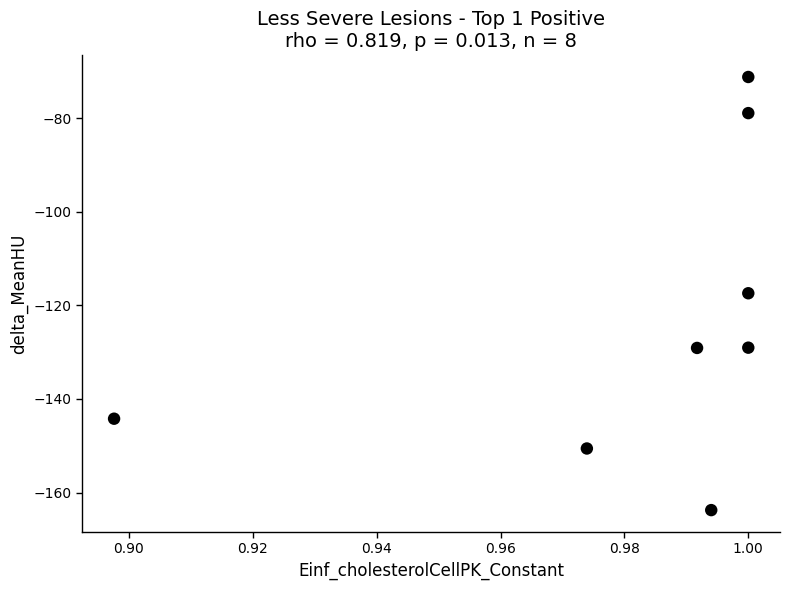

Saved plot: cool_Einf_cholesterolCellPK_Constant_vs_delta_MeanHU.svg


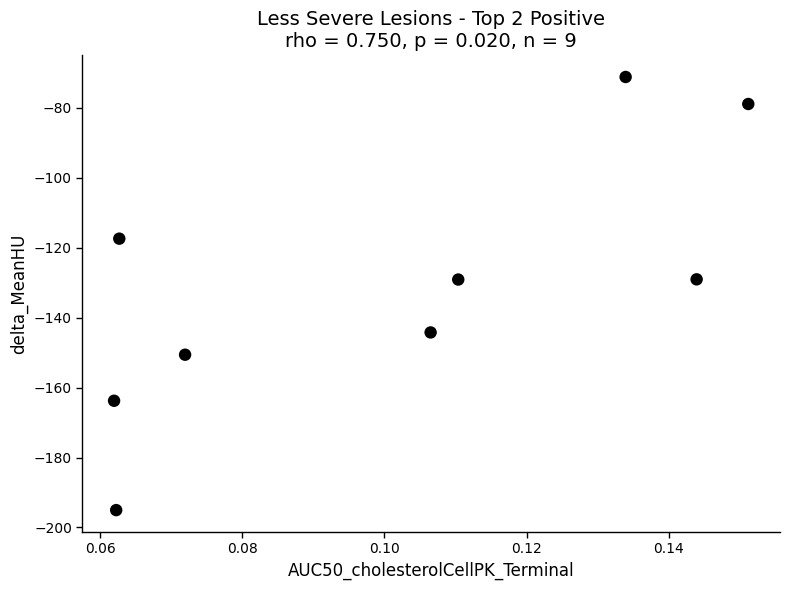

Saved plot: cool_AUC50_cholesterolCellPK_Terminal_vs_delta_MeanHU.svg
Skipping AUC50_cholesterolCasPK_Constant vs delta_MeanHU in cool: p-value 0.058 > 0.05
Skipping AUC50_cholesterolCellPK_Terminal vs TP6_MeanHU in cool: p-value 0.077 > 0.05


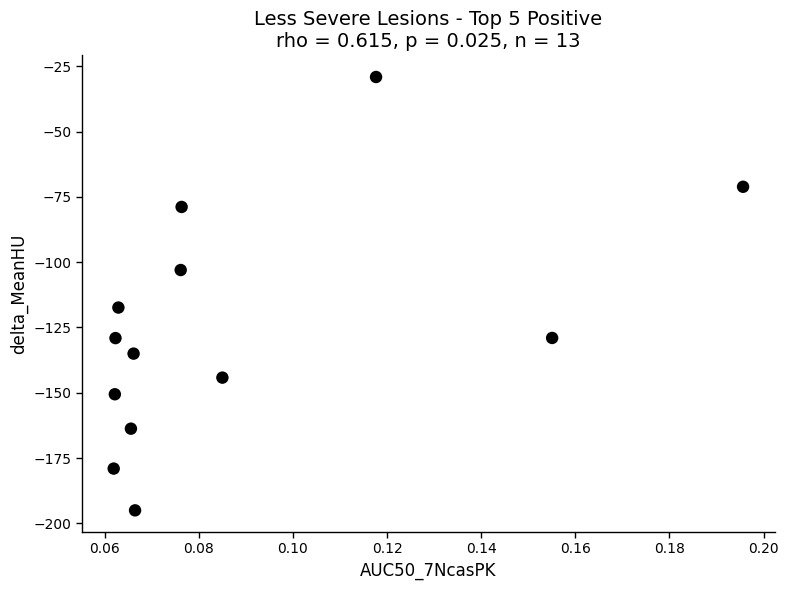

Saved plot: cool_AUC50_7NcasPK_vs_delta_MeanHU.svg


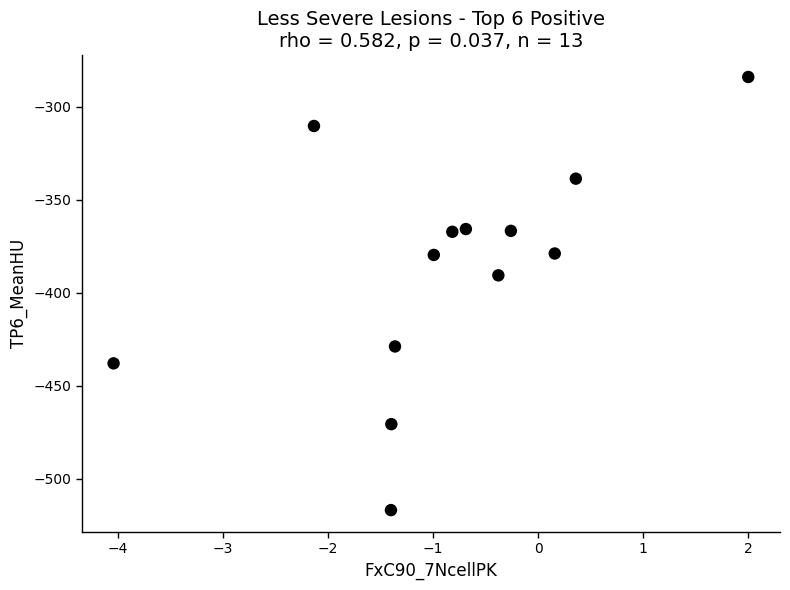

Saved plot: cool_FxC90_7NcellPK_vs_TP6_MeanHU.svg


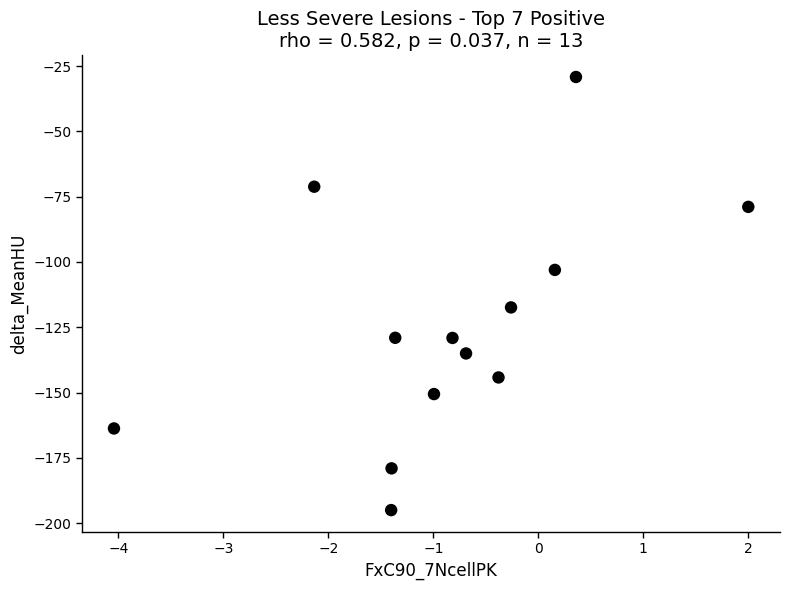

Saved plot: cool_FxC90_7NcellPK_vs_delta_MeanHU.svg
Skipping GRmax_butyrate_Constant vs delta_MeanHU in cool: p-value 0.097 > 0.05
Skipping Einf_5NcellPK vs TP6_MeanHU in cool: p-value 0.078 > 0.05
Skipping AUC50_dormancy_Terminal vs delta_MeanHU in cool: p-value 0.098 > 0.05


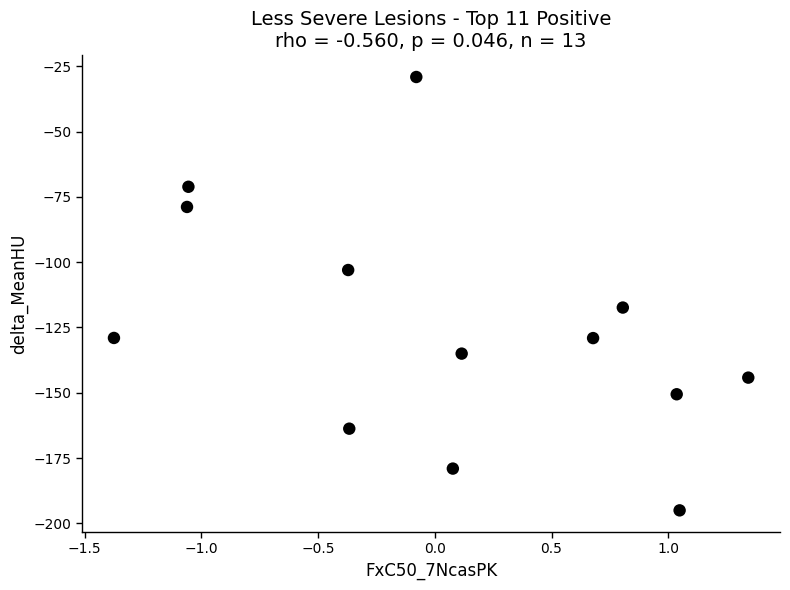

Saved plot: cool_FxC50_7NcasPK_vs_delta_MeanHU.svg
Skipping FxC50_dormancyCasPK_Constant vs TP6_MeanHU in cool: p-value 0.088 > 0.05
Skipping FxC50_butyrateCellPK_Terminal vs TP6_MeanHU in cool: p-value 0.077 > 0.05


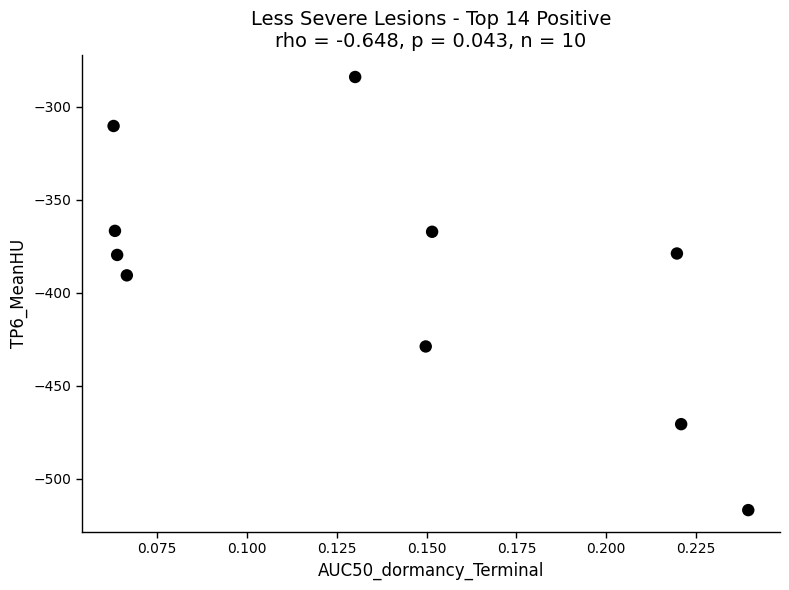

Saved plot: cool_AUC50_dormancy_Terminal_vs_TP6_MeanHU.svg


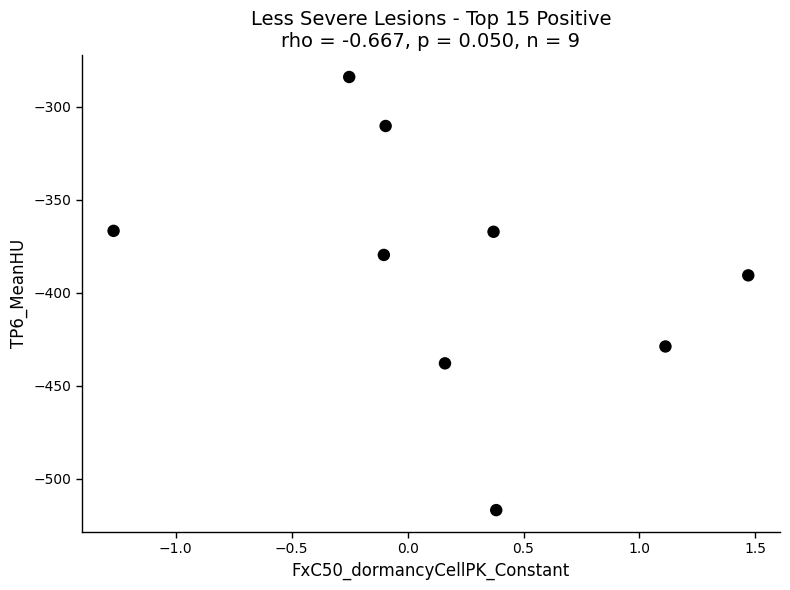

Saved plot: cool_FxC50_dormancyCellPK_Constant_vs_TP6_MeanHU.svg


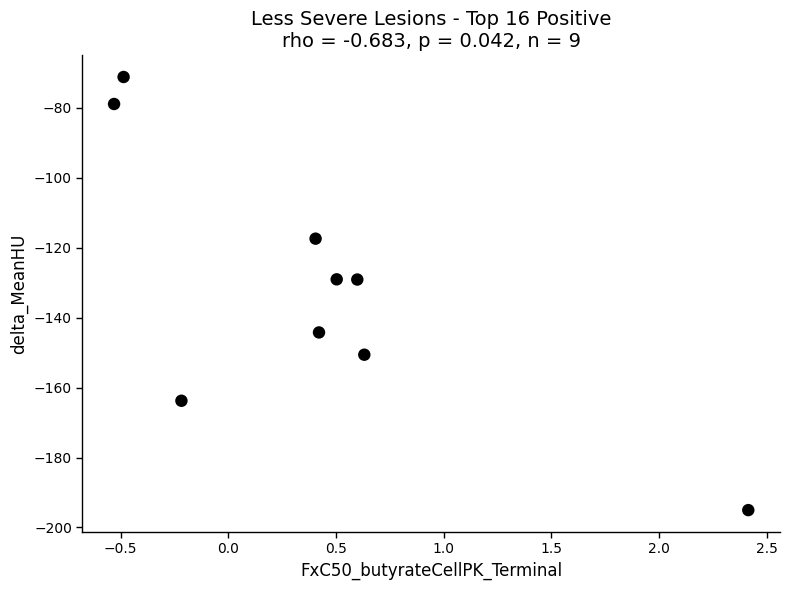

Saved plot: cool_FxC50_butyrateCellPK_Terminal_vs_delta_MeanHU.svg


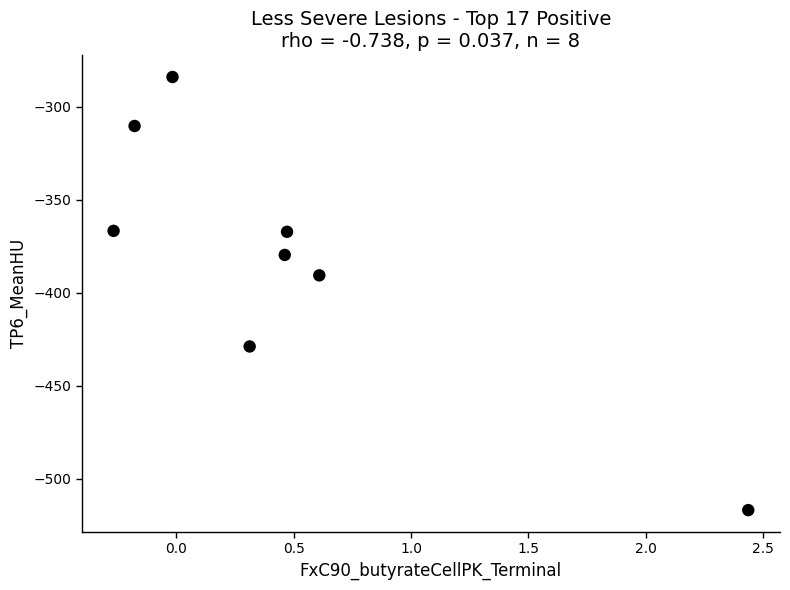

Saved plot: cool_FxC90_butyrateCellPK_Terminal_vs_TP6_MeanHU.svg


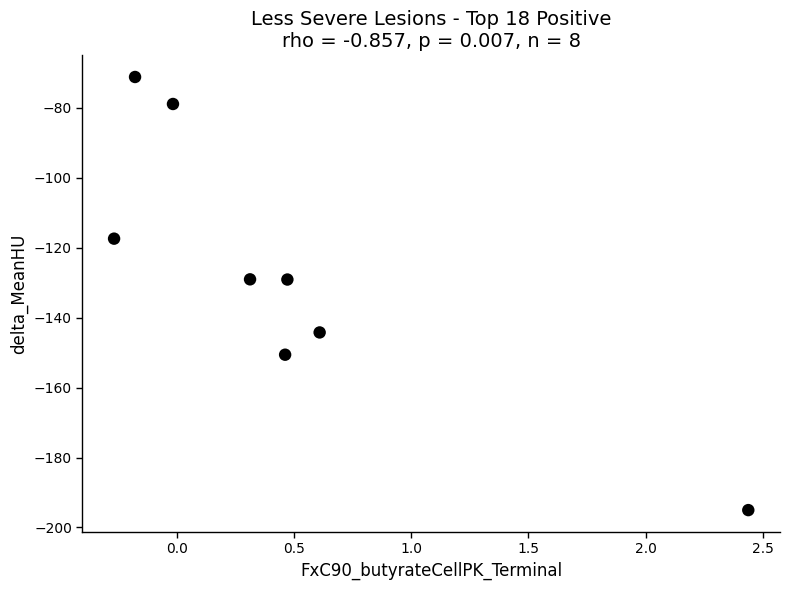

Saved plot: cool_FxC90_butyrateCellPK_Terminal_vs_delta_MeanHU.svg

Creating plots for LESS SEVERE lesions (top negative):


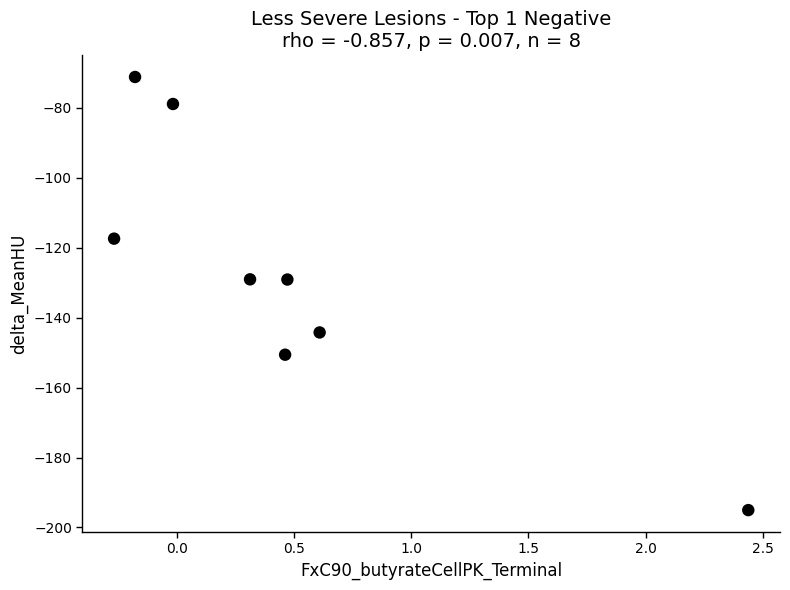

Saved plot: cool_FxC90_butyrateCellPK_Terminal_vs_delta_MeanHU.svg


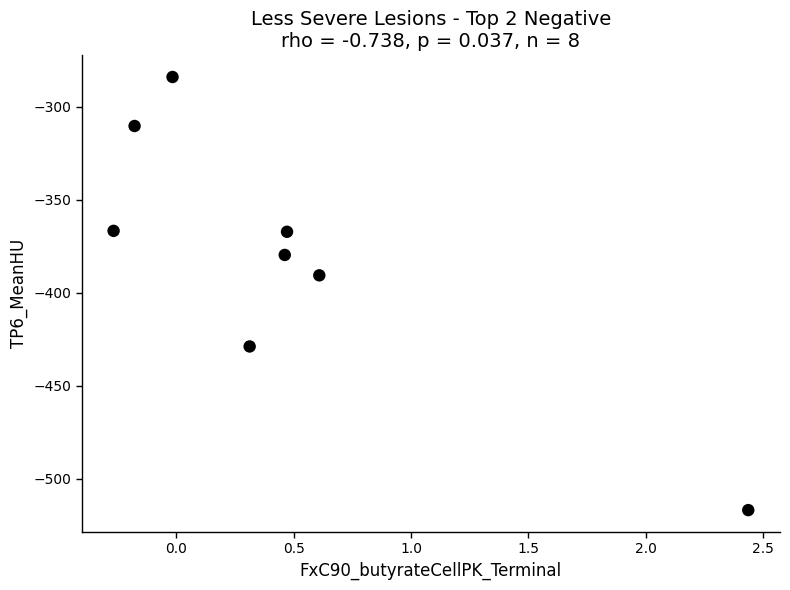

Saved plot: cool_FxC90_butyrateCellPK_Terminal_vs_TP6_MeanHU.svg


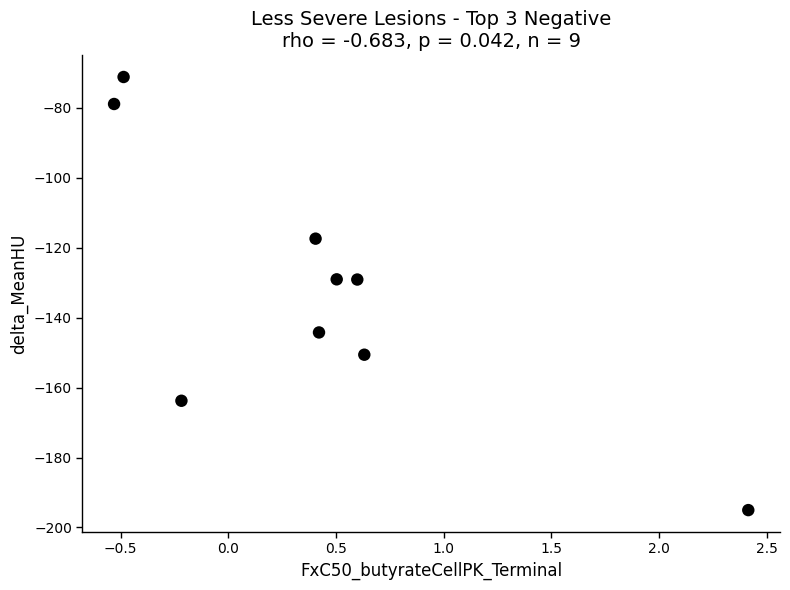

Saved plot: cool_FxC50_butyrateCellPK_Terminal_vs_delta_MeanHU.svg


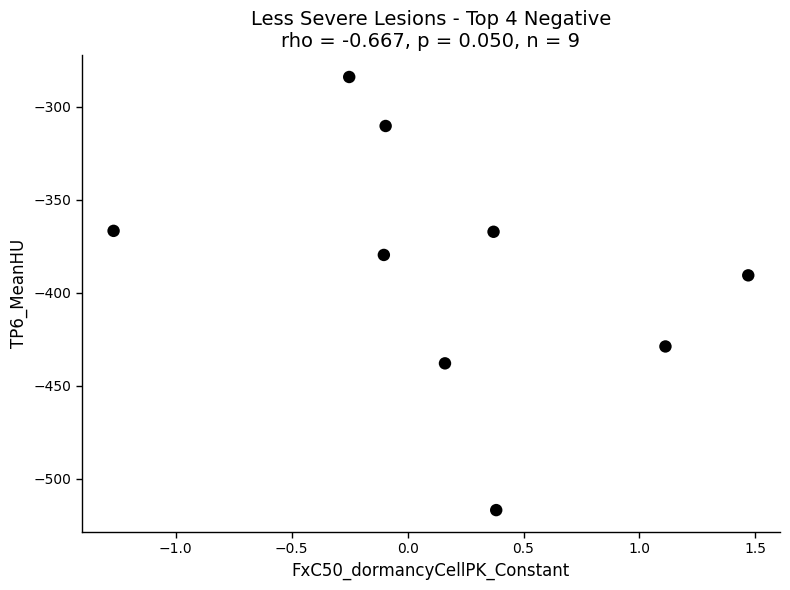

Saved plot: cool_FxC50_dormancyCellPK_Constant_vs_TP6_MeanHU.svg


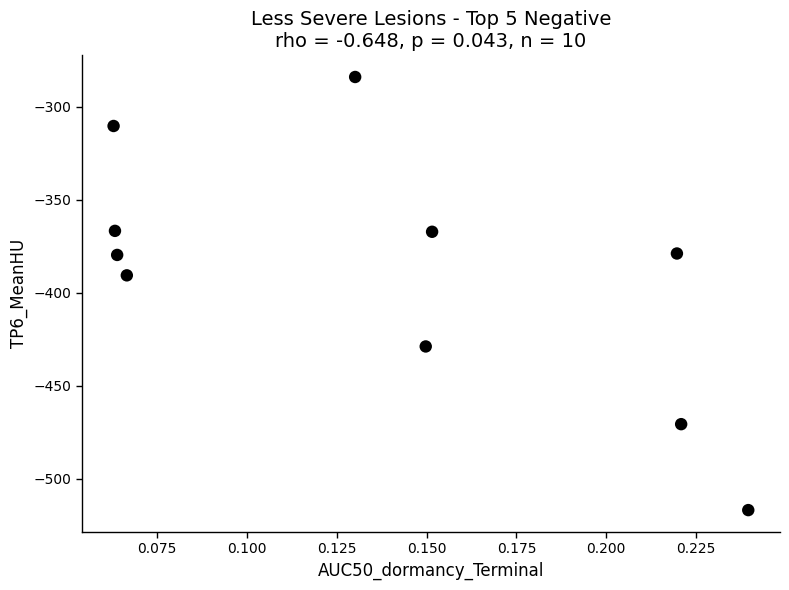

Saved plot: cool_AUC50_dormancy_Terminal_vs_TP6_MeanHU.svg
Skipping FxC50_butyrateCellPK_Terminal vs TP6_MeanHU in cool: p-value 0.077 > 0.05
Skipping FxC50_dormancyCasPK_Constant vs TP6_MeanHU in cool: p-value 0.088 > 0.05


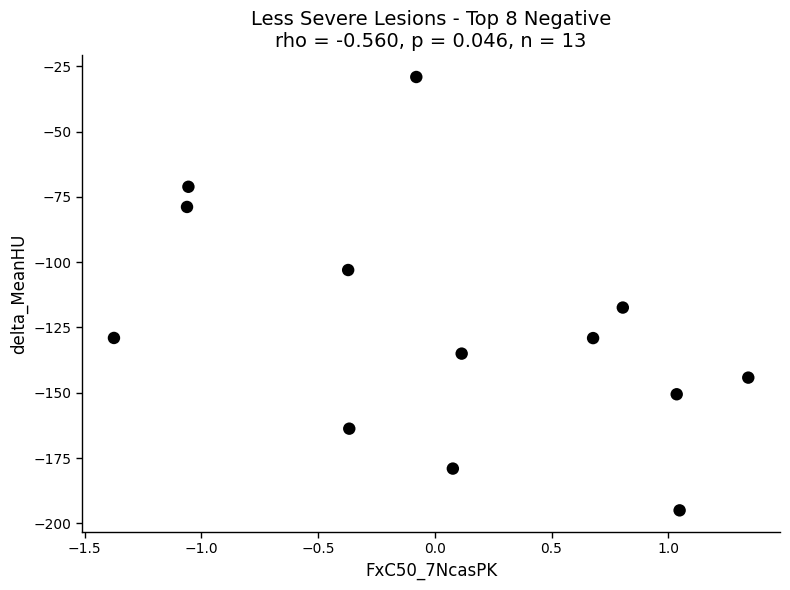

Saved plot: cool_FxC50_7NcasPK_vs_delta_MeanHU.svg
Skipping AUC50_dormancy_Terminal vs delta_MeanHU in cool: p-value 0.098 > 0.05
Skipping Einf_5NcellPK vs TP6_MeanHU in cool: p-value 0.078 > 0.05
Skipping GRmax_butyrate_Constant vs delta_MeanHU in cool: p-value 0.097 > 0.05


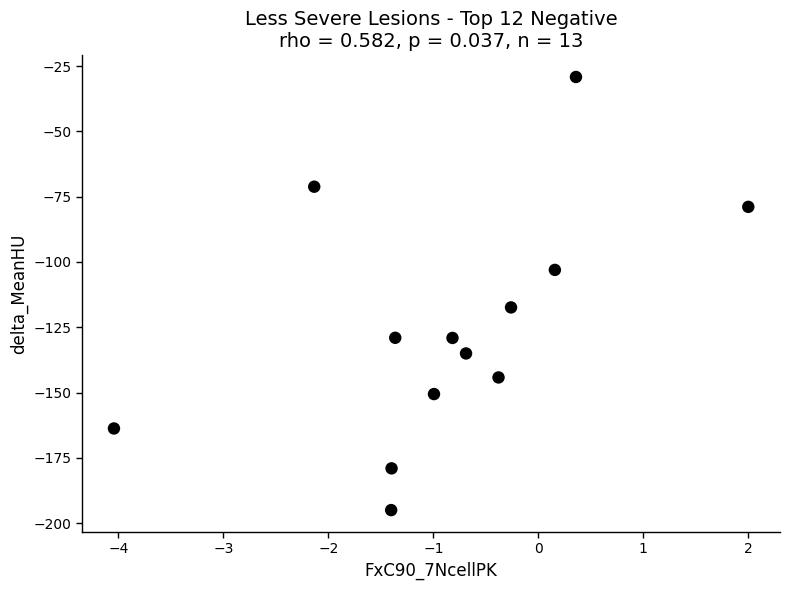

Saved plot: cool_FxC90_7NcellPK_vs_delta_MeanHU.svg


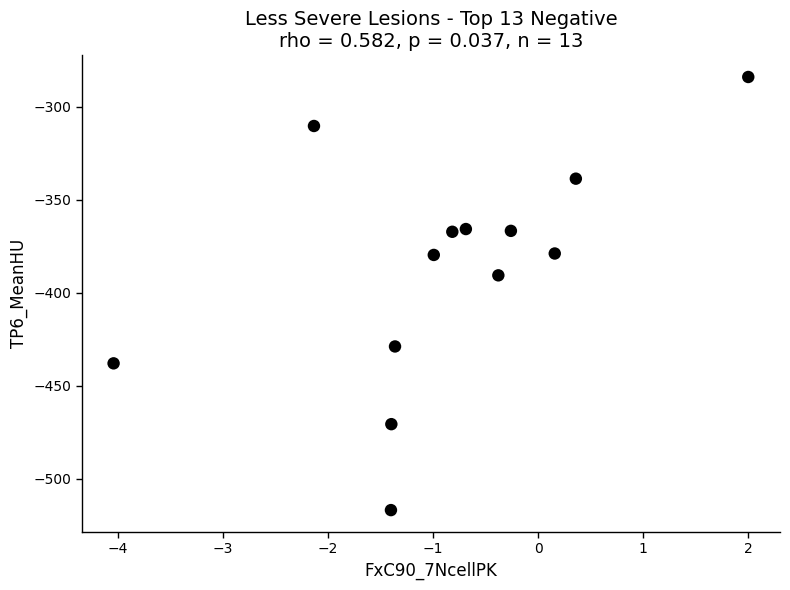

Saved plot: cool_FxC90_7NcellPK_vs_TP6_MeanHU.svg


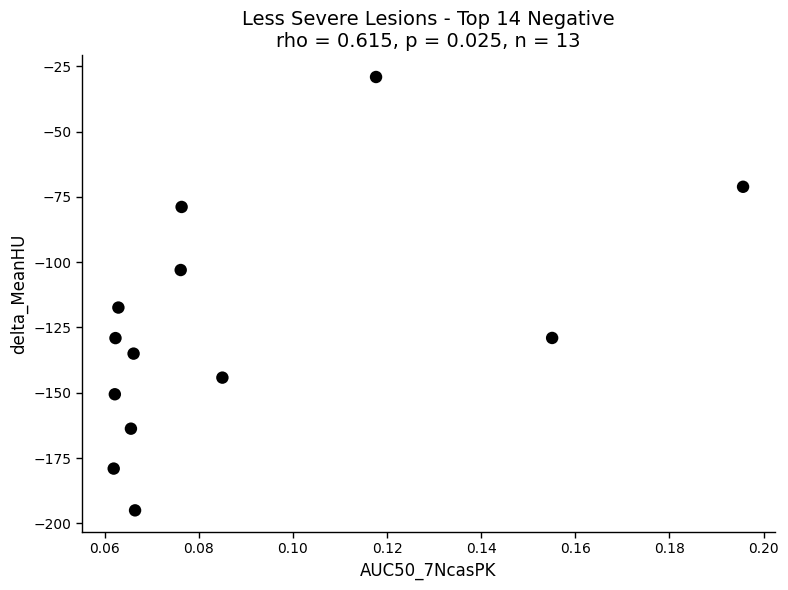

Saved plot: cool_AUC50_7NcasPK_vs_delta_MeanHU.svg
Skipping AUC50_cholesterolCellPK_Terminal vs TP6_MeanHU in cool: p-value 0.077 > 0.05
Skipping AUC50_cholesterolCasPK_Constant vs delta_MeanHU in cool: p-value 0.058 > 0.05


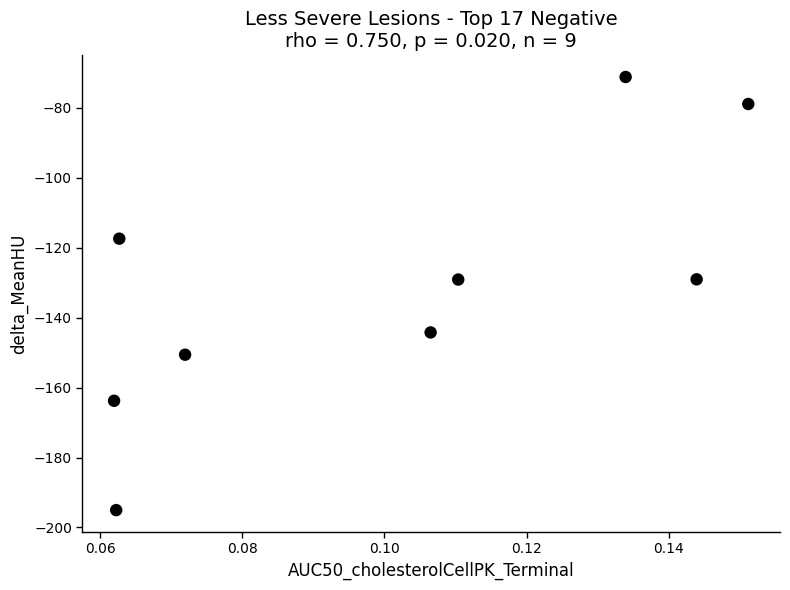

Saved plot: cool_AUC50_cholesterolCellPK_Terminal_vs_delta_MeanHU.svg


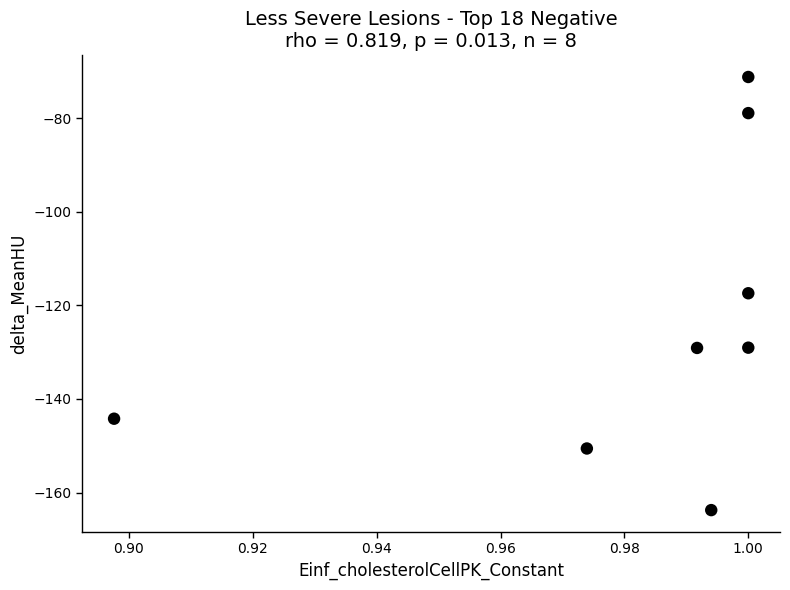

Saved plot: cool_Einf_cholesterolCellPK_Constant_vs_delta_MeanHU.svg


In [52]:
# Create scatter plots for top correlations

# Less severe lesions - top positive correlations
print("\nCreating plots for LESS SEVERE lesions (top positive):")
for i, corr in enumerate(less_top_pos, 1):
    create_correlation_scatter_plot(
        in_vitro_df, delta_df,
        corr['iv_feature'], corr['path_feature'],
        'cool',
    title_suffix=f" - Top {i} Positive"
    )

# Less severe lesions - top negative correlations  
print("\nCreating plots for LESS SEVERE lesions (top negative):")
for i, corr in enumerate(less_top_neg, 1):
    create_correlation_scatter_plot(
        in_vitro_df, delta_df,
        corr['iv_feature'], corr['path_feature'],
        'cool',
        title_suffix=f" - Top {i} Negative"
    )


Creating plots for SEVERE lesions (top positive):


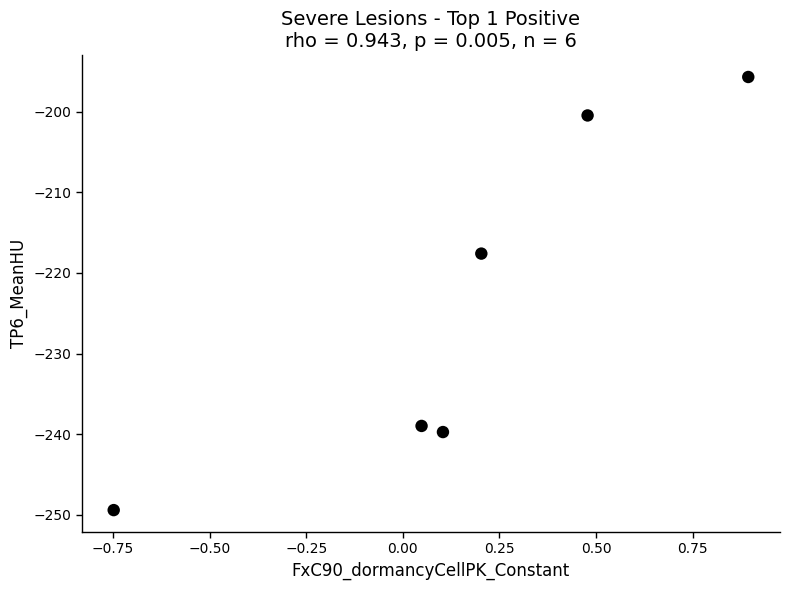

Saved plot: hot_FxC90_dormancyCellPK_Constant_vs_TP6_MeanHU.svg


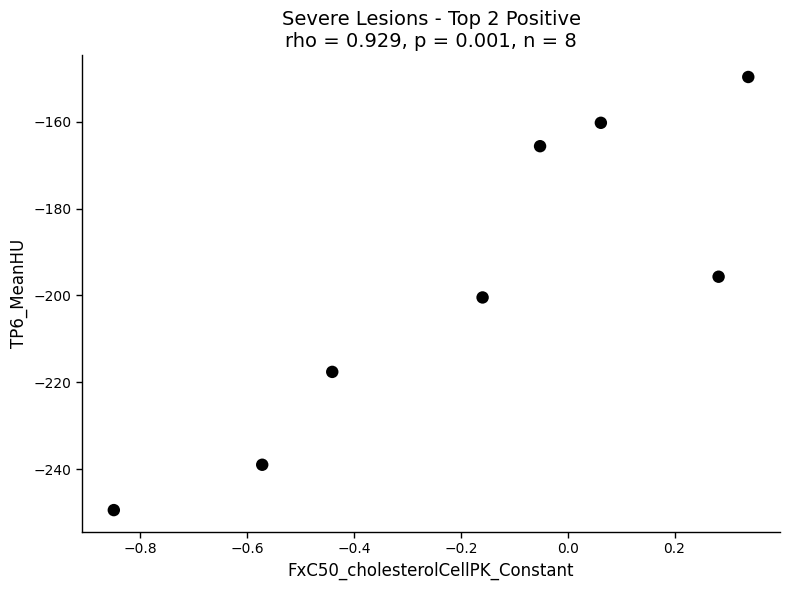

Saved plot: hot_FxC50_cholesterolCellPK_Constant_vs_TP6_MeanHU.svg


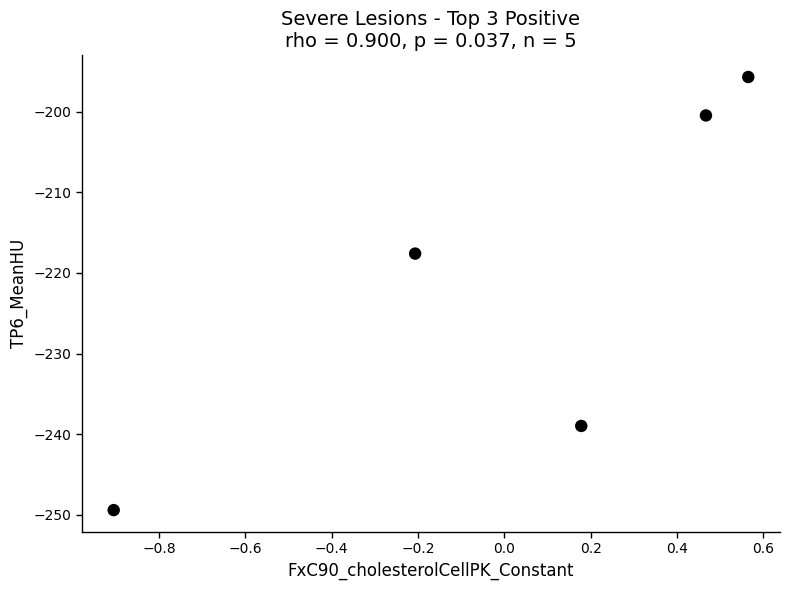

Saved plot: hot_FxC90_cholesterolCellPK_Constant_vs_TP6_MeanHU.svg


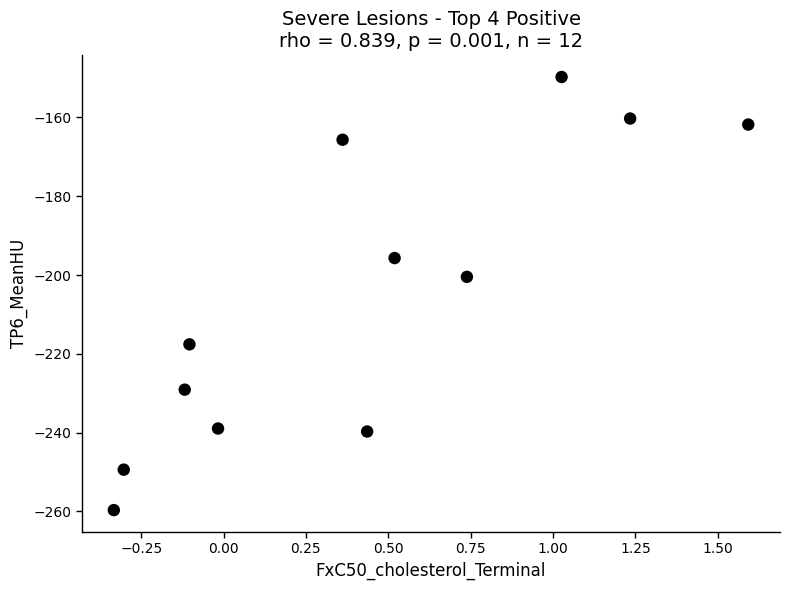

Saved plot: hot_FxC50_cholesterol_Terminal_vs_TP6_MeanHU.svg


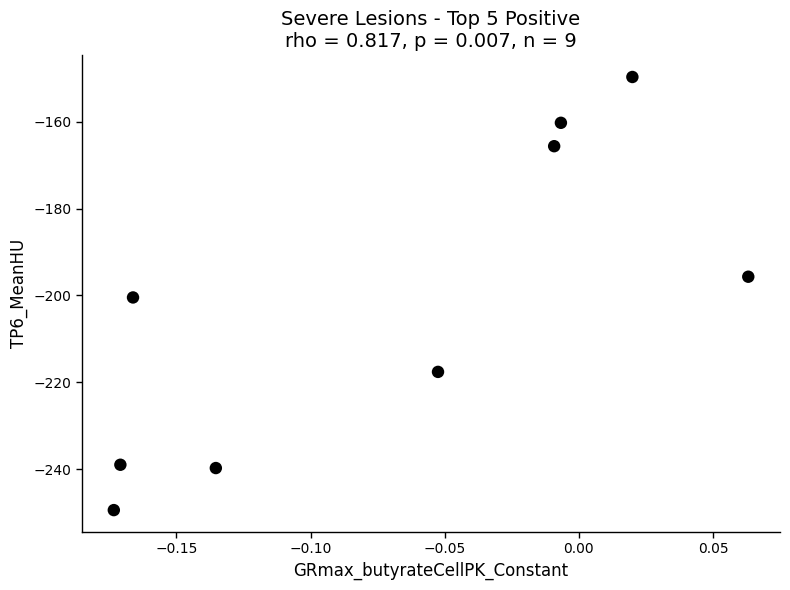

Saved plot: hot_GRmax_butyrateCellPK_Constant_vs_TP6_MeanHU.svg


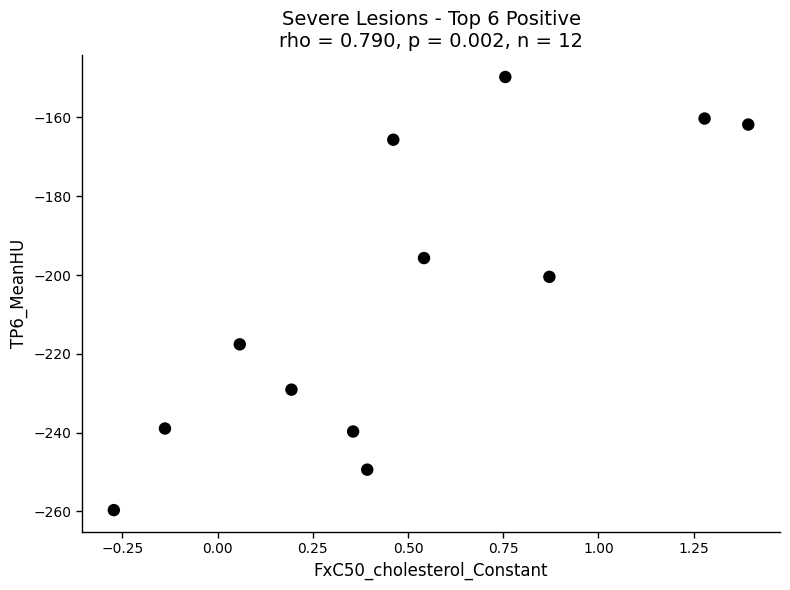

Saved plot: hot_FxC50_cholesterol_Constant_vs_TP6_MeanHU.svg


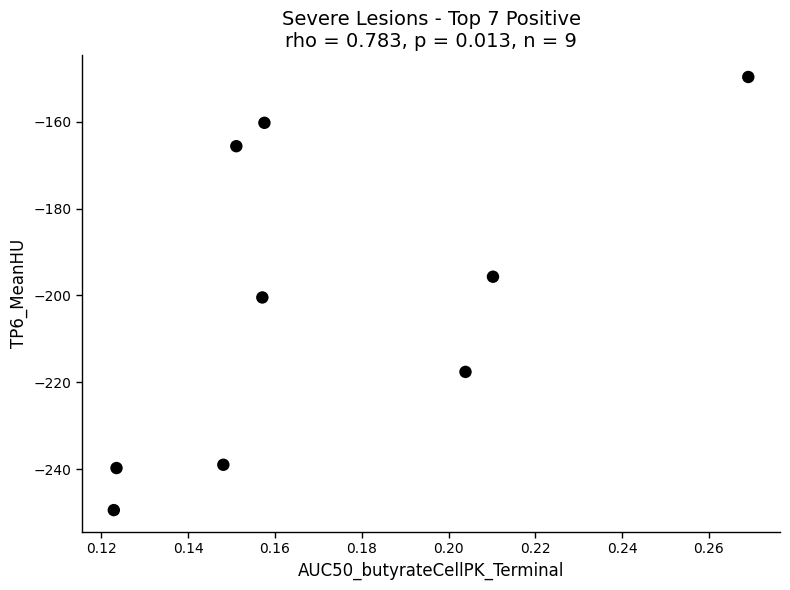

Saved plot: hot_AUC50_butyrateCellPK_Terminal_vs_TP6_MeanHU.svg


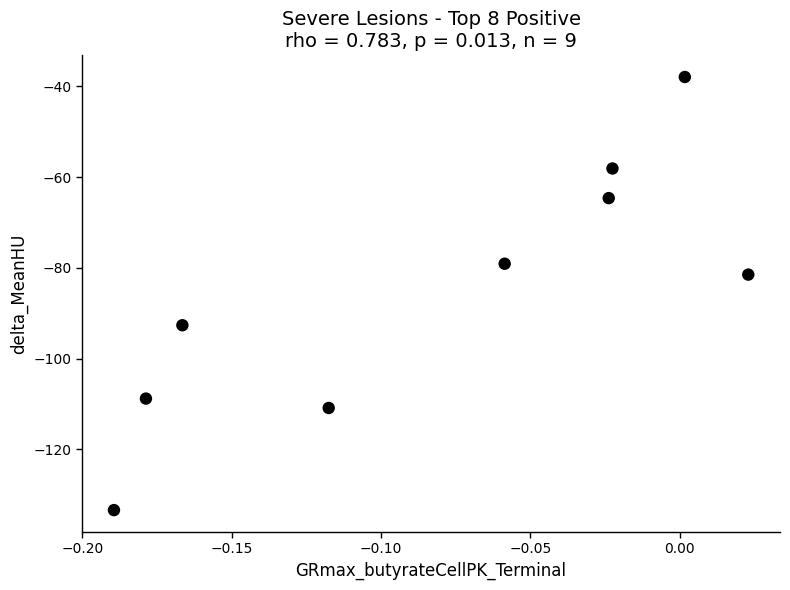

Saved plot: hot_GRmax_butyrateCellPK_Terminal_vs_delta_MeanHU.svg


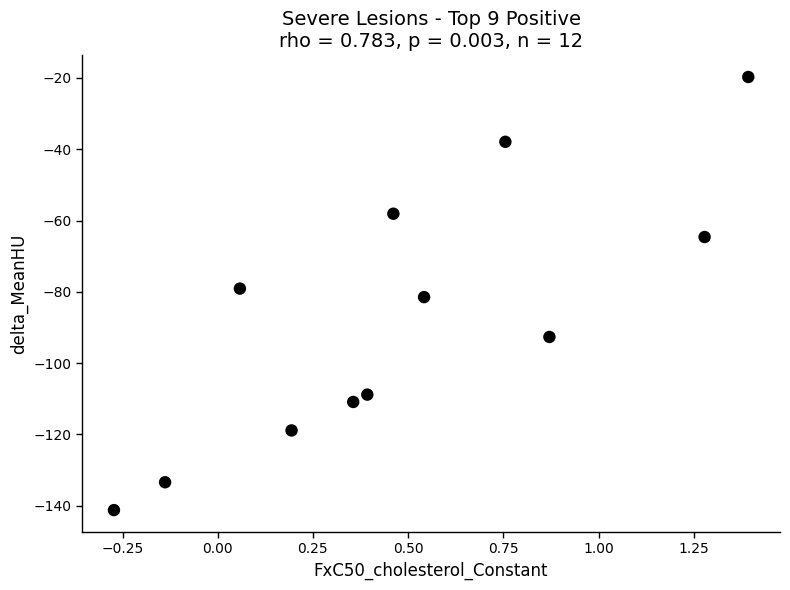

Saved plot: hot_FxC50_cholesterol_Constant_vs_delta_MeanHU.svg


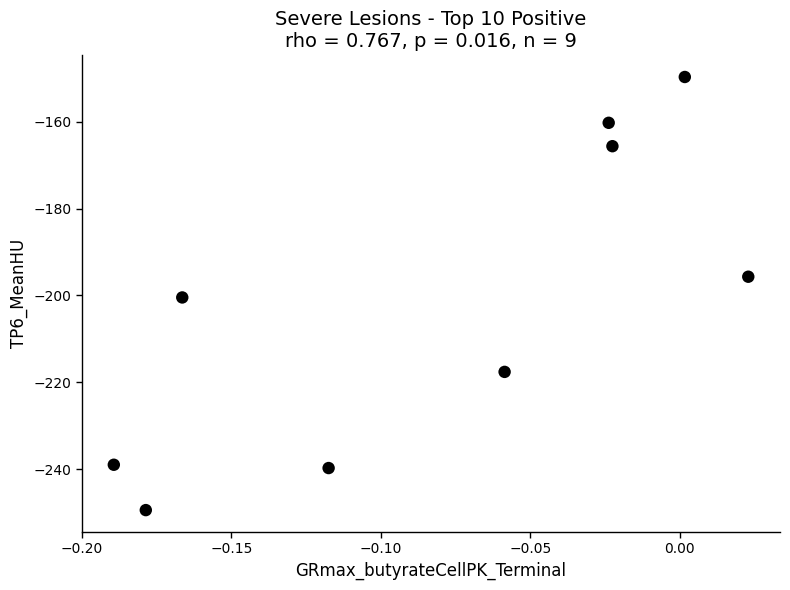

Saved plot: hot_GRmax_butyrateCellPK_Terminal_vs_TP6_MeanHU.svg

Creating plots for SEVERE lesions (top negative):


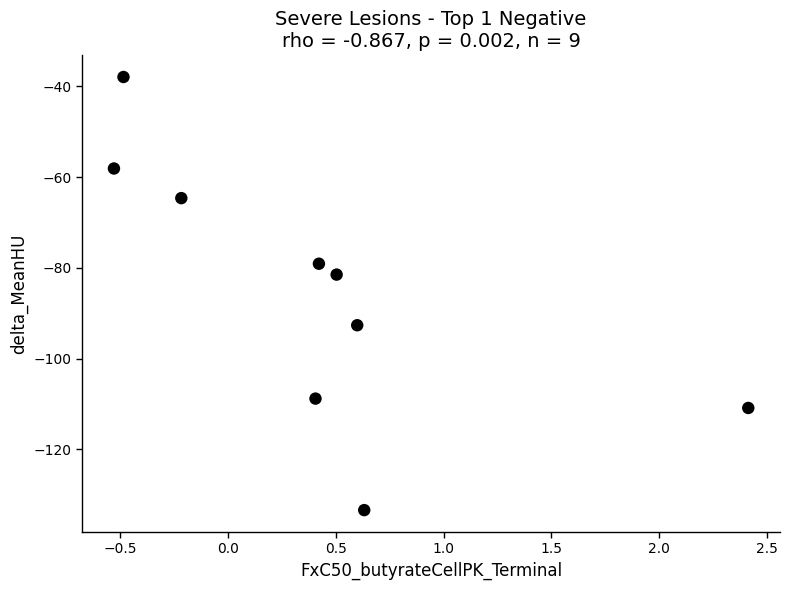

Saved plot: hot_FxC50_butyrateCellPK_Terminal_vs_delta_MeanHU.svg


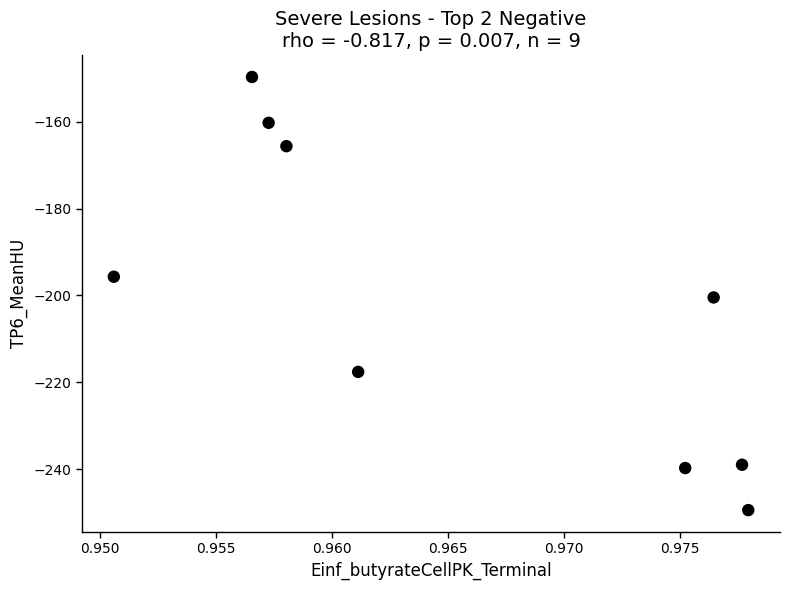

Saved plot: hot_Einf_butyrateCellPK_Terminal_vs_TP6_MeanHU.svg


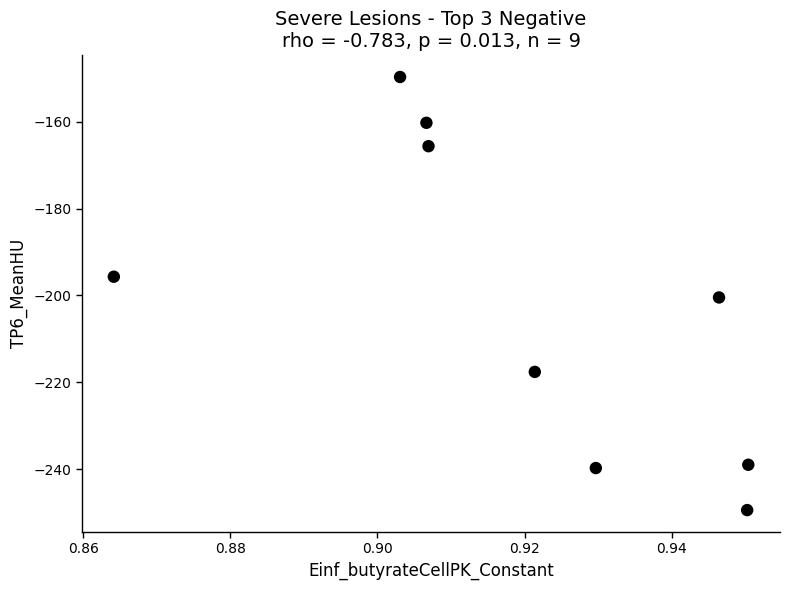

Saved plot: hot_Einf_butyrateCellPK_Constant_vs_TP6_MeanHU.svg


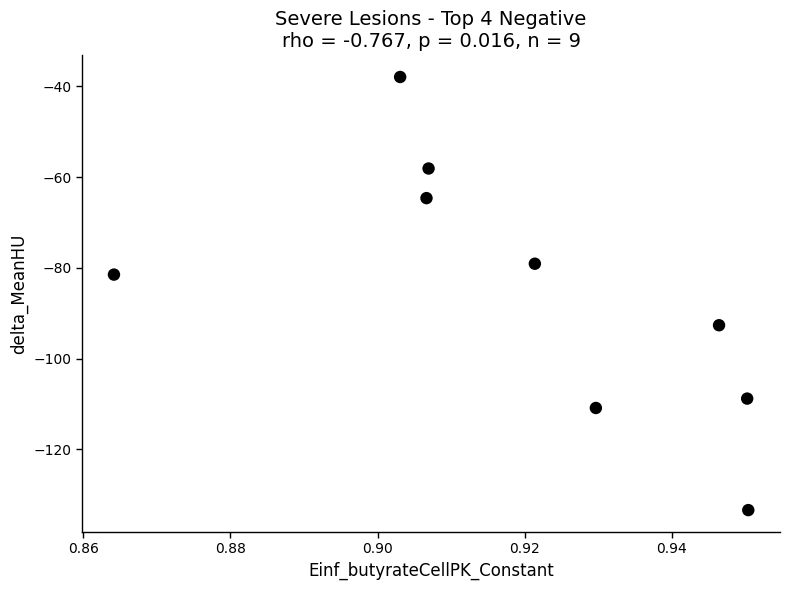

Saved plot: hot_Einf_butyrateCellPK_Constant_vs_delta_MeanHU.svg


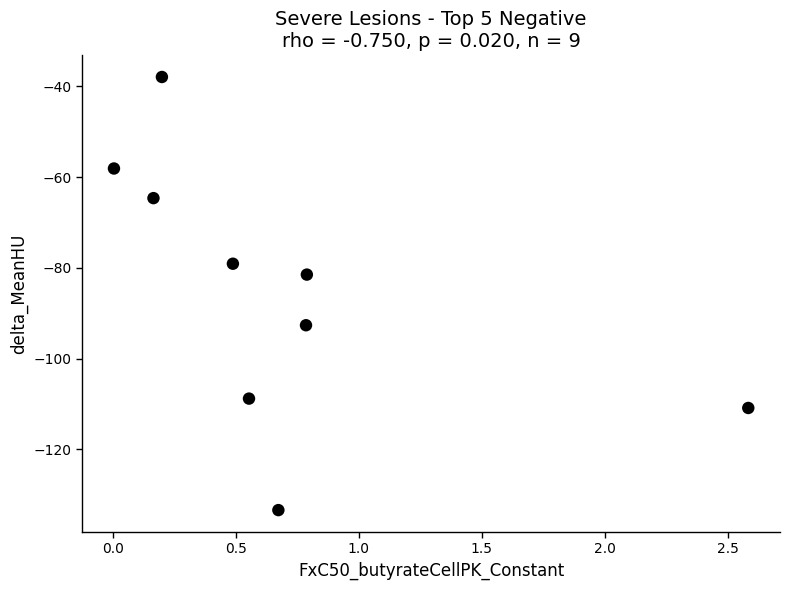

Saved plot: hot_FxC50_butyrateCellPK_Constant_vs_delta_MeanHU.svg


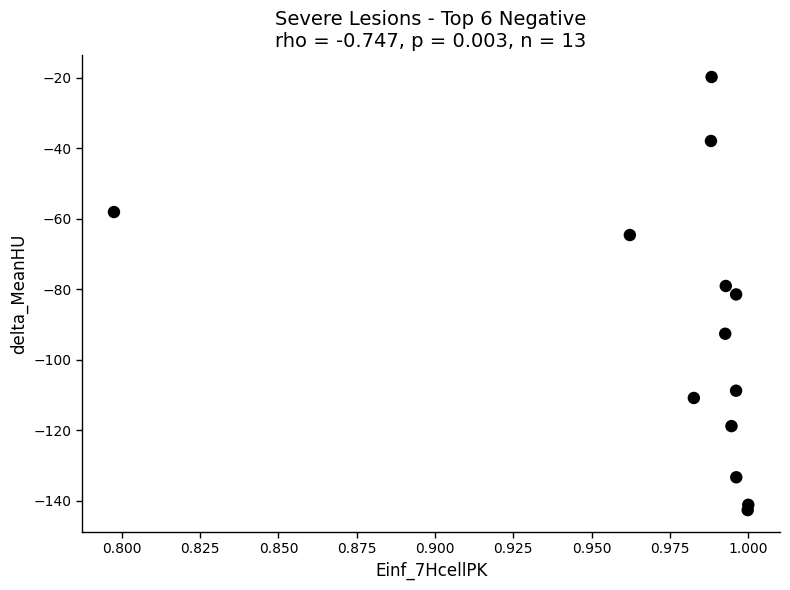

Saved plot: hot_Einf_7HcellPK_vs_delta_MeanHU.svg


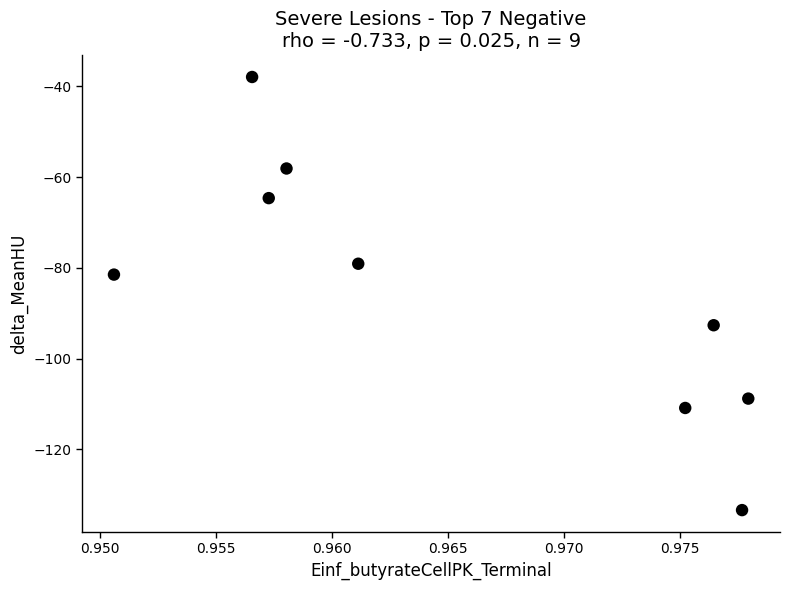

Saved plot: hot_Einf_butyrateCellPK_Terminal_vs_delta_MeanHU.svg


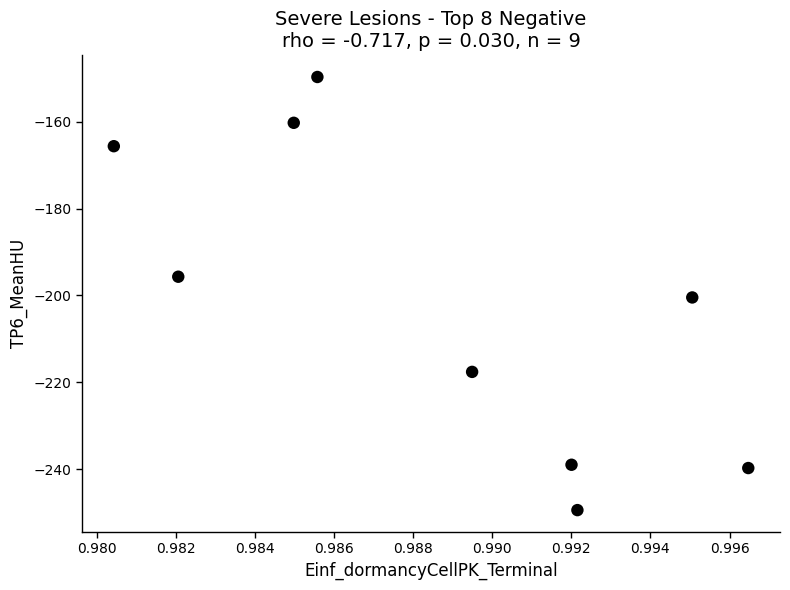

Saved plot: hot_Einf_dormancyCellPK_Terminal_vs_TP6_MeanHU.svg


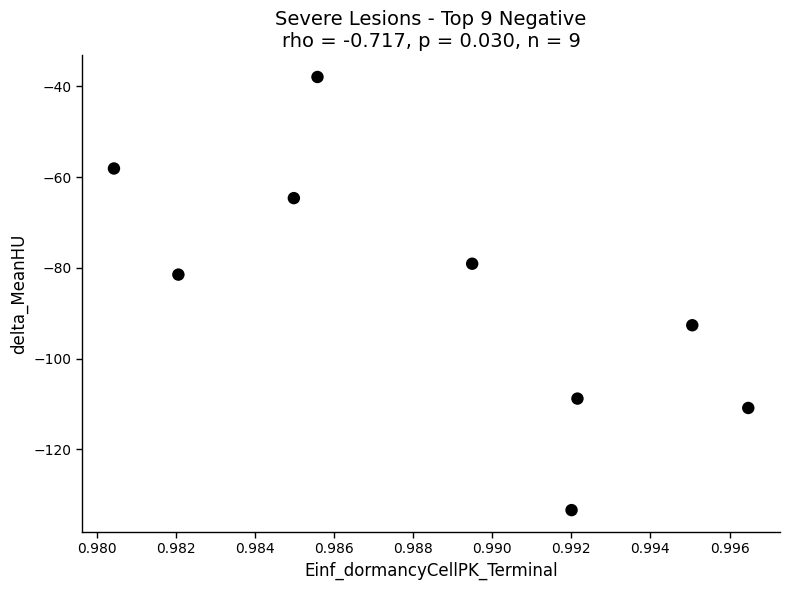

Saved plot: hot_Einf_dormancyCellPK_Terminal_vs_delta_MeanHU.svg


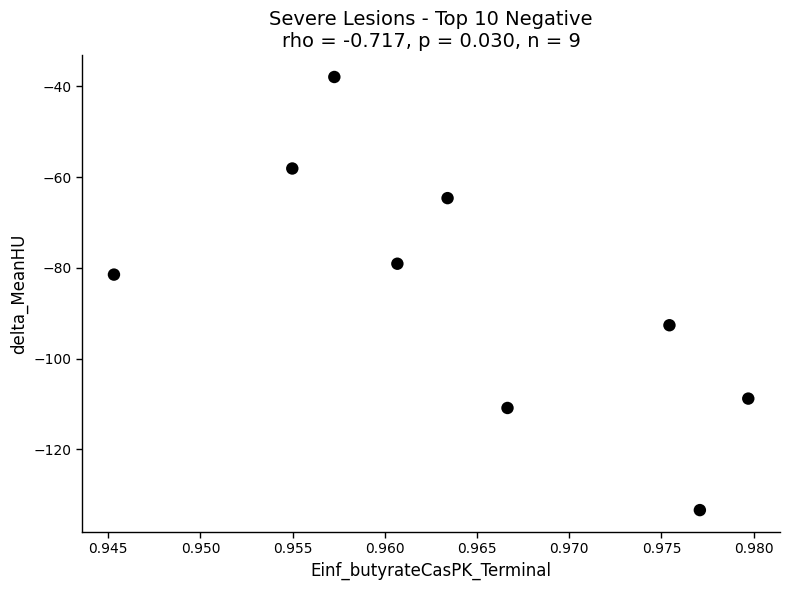

Saved plot: hot_Einf_butyrateCasPK_Terminal_vs_delta_MeanHU.svg


In [45]:
# Create scatter plots for top correlations

# Less severe lesions - top positive correlations
print("\nCreating plots for SEVERE lesions (top positive):")
for i, corr in enumerate(severe_top_pos, 1):
    create_correlation_scatter_plot(
        in_vitro_df, delta_df,
        corr['iv_feature'], corr['path_feature'],
        'hot',
    title_suffix=f" - Top {i} Positive"
    )

# Less severe lesions - top negative correlations  
print("\nCreating plots for SEVERE lesions (top negative):")
for i, corr in enumerate(severe_top_neg, 1):
    create_correlation_scatter_plot(
        in_vitro_df, delta_df,
        corr['iv_feature'], corr['path_feature'],
        'hot',
        title_suffix=f" - Top {i} Negative"
    )